In [1]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!mkdir -p /content/DDR

!unzip -q "/content/drive/MyDrive/DL_Project/DDR/DDR.zip" \
-d /content/DDR

unzip:  cannot find or open /content/drive/MyDrive/DL_Project/DDR/DDR.zip, /content/drive/MyDrive/DL_Project/DDR/DDR.zip.zip or /content/drive/MyDrive/DL_Project/DDR/DDR.zip.ZIP.


In [4]:
!ls "/content/drive/MyDrive/DL Project"

DDR.zip


In [5]:
import os

zip_path = "/content/drive/MyDrive/DL Project/DDR.zip"

print("File exists:", os.path.exists(zip_path))

File exists: True


In [6]:
!mkdir -p "/content/DDR"

In [7]:
!unzip -q "/content/drive/MyDrive/DL Project/DDR.zip" -d "/content/DDR"

In [8]:
!ls "/content/DDR"

DR_grading  DR_grading.csv


In [9]:
import os

DATASET_PATH = "/content/DDR"

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)

    if level < 3:
        indent = "    " * level
        print(f"{indent}{os.path.basename(root)}/")

        for file in files[:10]:
            print(f"{indent}    {file}")

DDR/
    DR_grading.csv
    DR_grading/
        DR_grading/
            007-0410-000.jpg
            007-5909-300.jpg
            007-1842-100.jpg
            007-4440-200.jpg
            20170424095919157.jpg
            007-1148-000.jpg
            20170427184002642.jpg
            20170612163236281.jpg
            007-5389-300.jpg
            007-0594-000.jpg


In [10]:
import os

CSV_PATH = "/content/DDR/DR_grading.csv"
IMAGE_DIR = "/content/DDR/DR_grading/DR_grading"

print("CSV exists:", os.path.exists(CSV_PATH))
print("Image folder exists:", os.path.exists(IMAGE_DIR))

CSV exists: True
Image folder exists: True


In [11]:
import pandas as pd

df = pd.read_csv(CSV_PATH)

print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nShape:", df.shape)

                 id_code  diagnosis
0  20170413102628830.jpg          0
1  20170413111955404.jpg          0
2  20170413112015395.jpg          0
3  20170413112017305.jpg          0
4  20170413112528859.jpg          0

Columns: ['id_code', 'diagnosis']

Shape: (12522, 2)


In [12]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
print(df['diagnosis'].value_counts().sort_index())

Missing values:
id_code      0
diagnosis    0
dtype: int64

Duplicate rows: 0

Class distribution:
diagnosis
0    6266
1     630
2    4477
3     236
4     913
Name: count, dtype: int64


In [13]:
df['filepath'] = df['id_code'].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)

df['exists'] = df['filepath'].apply(os.path.exists)

print("Total records:", len(df))
print("Images found:", df['exists'].sum())
print("Missing images:", (~df['exists']).sum())

Total records: 12522
Images found: 12522
Missing images: 0


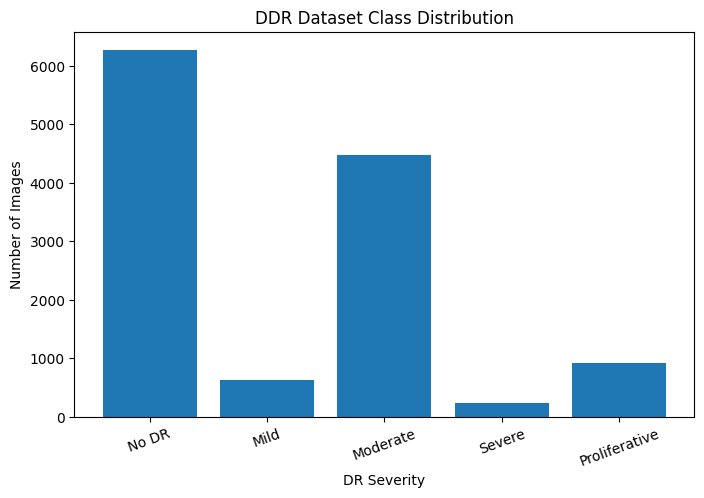

In [14]:
import matplotlib.pyplot as plt

class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative"
}

counts = df['diagnosis'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(
    [class_names[i] for i in counts.index],
    counts.values
)

plt.title("DDR Dataset Class Distribution")
plt.xlabel("DR Severity")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.show()

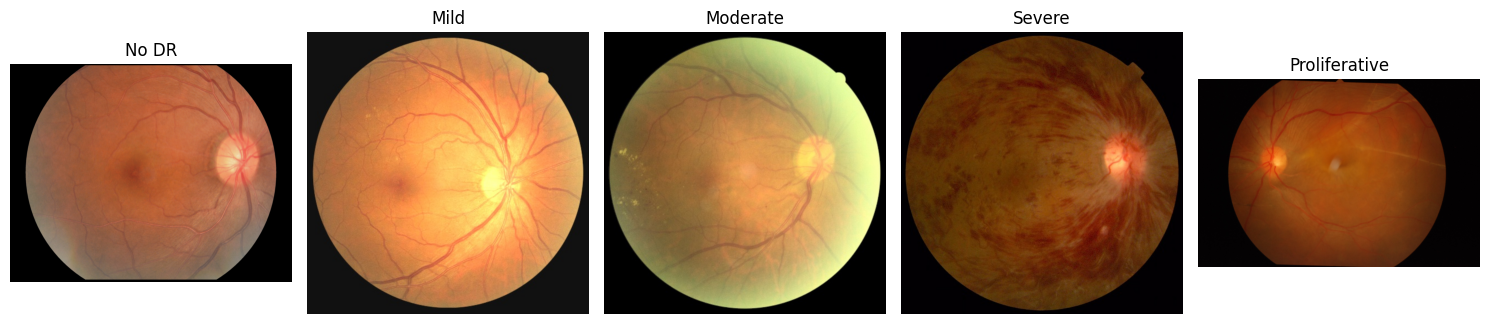

In [15]:
from PIL import Image

plt.figure(figsize=(15,4))

for label in range(5):
    sample = df[df['diagnosis'] == label].iloc[0]

    img = Image.open(sample['filepath'])

    plt.subplot(1,5,label+1)
    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

SEED = 42

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['diagnosis'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['diagnosis'],
    random_state=SEED
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 8765
Validation: 1878
Testing: 1879


In [17]:
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df['split'] = 'train'
val_df['split'] = 'validation'
test_df['split'] = 'test'

split_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

split_df.to_csv(
    "/content/drive/MyDrive/DL Project/ddr_common_split.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [18]:
import tensorflow as tf
import numpy as np
import random

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [19]:
def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

In [20]:
def create_dataset(dataframe, training=False):

    paths = dataframe['filepath'].values
    labels = dataframe['diagnosis'].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        dataset = dataset.shuffle(
            2000,
            seed=SEED
        )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [21]:
train_dataset = create_dataset(
    train_df,
    training=True
)

val_dataset = create_dataset(
    val_df
)

test_dataset = create_dataset(
    test_df
)

In [22]:
for images, labels in train_dataset.take(1):

    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


In [23]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.05
    ),

    tf.keras.layers.RandomZoom(
        0.10
    ),

    tf.keras.layers.RandomContrast(
        0.10
    )
])

In [24]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(
    train_df['diagnosis']
)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['diagnosis']
)

class_weights = dict(
    zip(classes, weights)
)

print(class_weights)

{np.int64(0): np.float64(0.3996808025535796), np.int64(1): np.float64(3.9750566893424035), np.int64(2): np.float64(0.5593490746649649), np.int64(3): np.float64(10.624242424242425), np.int64(4): np.float64(2.7433489827856024)}


In [25]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([

    layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.BatchNormalization(),

    layers.Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.BatchNormalization(),

    layers.Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.BatchNormalization(),

    layers.Conv2D(
        256,
        (3,3),
        padding='same',
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.4),

    layers.Dense(
        5,
        activation='softmax'
    )
])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,877 (1.62 MB)

 Trainable params: 422,917 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [26]:
cnn_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [27]:
import os

RESULT_DIR = "/content/drive/MyDrive/DL Project/CNN_Results"

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

In [28]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        f"{RESULT_DIR}/best_cnn.keras",
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

In [29]:
history = cnn_model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=20,

    class_weight=class_weights,

    callbacks=callbacks
)

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.2334 - loss: 1.7564
Epoch 1: val_loss improved from None to 1.44060, saving model to /content/drive/MyDrive/DL Project/CNN_Results/best_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DL Project/CNN_Results/best_cnn.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 88s 242ms/step - accuracy: 0.2687 - loss: 1.6593 - val_accuracy: 0.3450 - val_loss: 1.4406 - learning_rate: 0.0010
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.3181 - loss: 1.6134
Epoch 2: val_loss did not improve from 1.44060
274/274 ━━━━━━━━━━━━━━━━━━━━ 82s 255ms/step - accuracy: 0.3461 - loss: 1.5878 - val_accuracy: 0.3589 - val_loss: 1.5193 - learning_rate: 0.0010
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.2968 - loss: 1.6181
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 1.44060
274/274 ━━━━━━━━━━━━━━━━━━━━ 71s 216ms/step - accuracy:

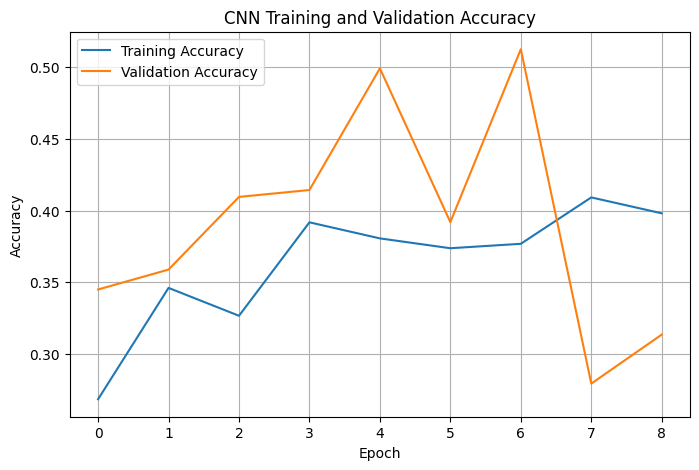

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.savefig(
    f"{RESULT_DIR}/cnn_accuracy.png",
    bbox_inches='tight'
)

plt.show()

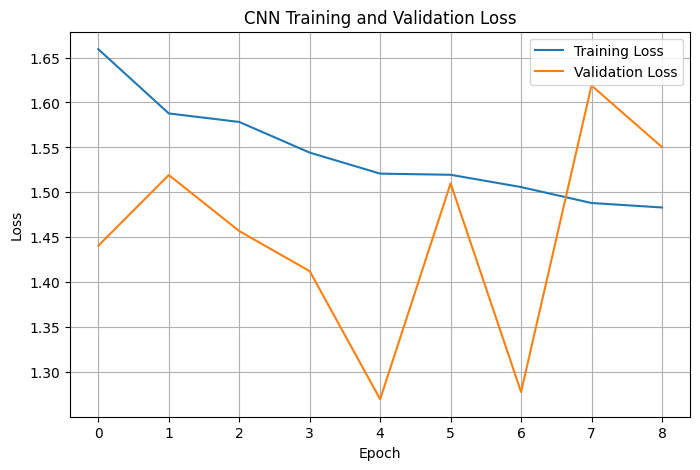

In [31]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid()

plt.savefig(
    f"{RESULT_DIR}/cnn_loss.png",
    bbox_inches='tight'
)

plt.show()

In [32]:
test_loss, test_accuracy = cnn_model.evaluate(
    test_dataset
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 206ms/step - accuracy: 0.5008 - loss: 1.2627
Test Loss: 1.2626562118530273
Test Accuracy: 0.5007982850074768


In [33]:
y_true = []
y_prob = []

for images, labels in test_dataset:

    predictions = cnn_model.predict(
        images,
        verbose=0
    )

    y_true.extend(
        labels.numpy()
    )

    y_prob.extend(
        predictions
    )

y_true = np.array(y_true)
y_prob = np.array(y_prob)

y_pred = np.argmax(
    y_prob,
    axis=1
)

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    roc_auc_score
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights='quadratic'
)

y_true_onehot = tf.keras.utils.to_categorical(
    y_true,
    num_classes=5
)

auc = roc_auc_score(
    y_true_onehot,
    y_prob,
    multi_class='ovr',
    average='macro'
)

print("Accuracy:", accuracy)
print("Macro Precision:", precision)
print("Macro Recall:", recall)
print("Macro F1:", f1)
print("ROC-AUC:", auc)
print("QWK:", qwk)

Accuracy: 0.5007982969664715
Macro Precision: 0.27506590999185254
Macro Recall: 0.27784820462789217
Macro F1: 0.24907945913698964
ROC-AUC: 0.6688393159593605
QWK: 0.26827507682831875


In [35]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "No DR",
            "Mild",
            "Moderate",
            "Severe",
            "Proliferative"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

        No DR       0.59      0.87      0.71       940
         Mild       0.08      0.08      0.08        95
     Moderate       0.47      0.13      0.21       672
       Severe       0.06      0.14      0.08        35
Proliferative       0.18      0.16      0.17       137

     accuracy                           0.50      1879
    macro avg       0.28      0.28      0.25      1879
 weighted avg       0.48      0.50      0.44      1879



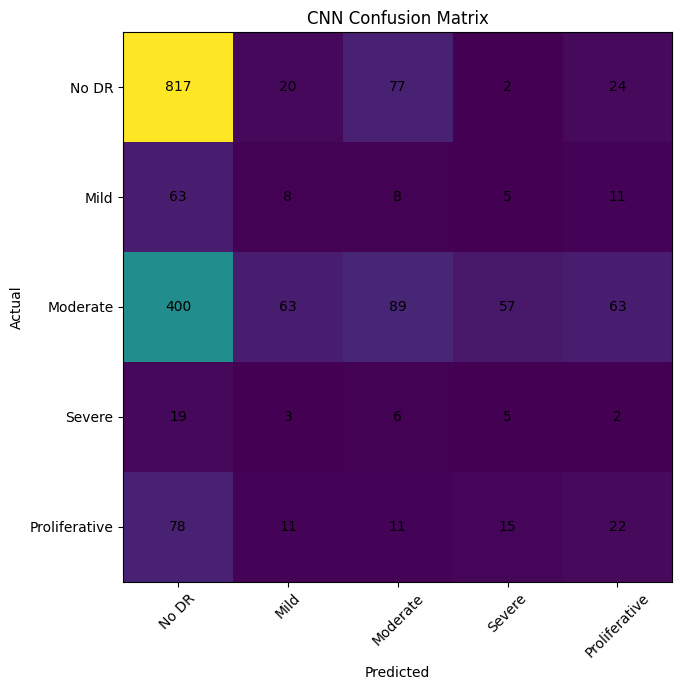

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

fig, ax = plt.subplots(figsize=(8,7))

im = ax.imshow(cm)

ax.set_xticks(range(5))
ax.set_yticks(range(5))

labels = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative"
]

ax.set_xticklabels(labels, rotation=45)
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("CNN Confusion Matrix")

for i in range(5):
    for j in range(5):
        ax.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    f"{RESULT_DIR}/cnn_confusion_matrix.png"
)

plt.show()

In [37]:
results = pd.DataFrame([{
    "Model": "Custom CNN",
    "Accuracy": accuracy,
    "Macro Precision": precision,
    "Macro Recall": recall,
    "Macro F1": f1,
    "ROC-AUC": auc,
    "QWK": qwk,
    "Parameters": cnn_model.count_params()
}])

results.to_csv(
    f"{RESULT_DIR}/cnn_metrics.csv",
    index=False
)

results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,ROC-AUC,QWK,Parameters
0,Custom CNN,0.500798,0.275066,0.277848,0.249079,0.668839,0.268275,423877
